In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# metadata
print(iris.metadata)

# variable information
print(iris.variables)

{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

In [3]:
class_names, class_counts= y["class"].unique(),y["class"].value_counts()
class_names, class_counts

(array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object),
 class
 Iris-setosa        50
 Iris-versicolor    50
 Iris-virginica     50
 Name: count, dtype: int64)

In [4]:
class_counts = y["class"].value_counts()
class_counts

,count
class,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [5]:
X

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


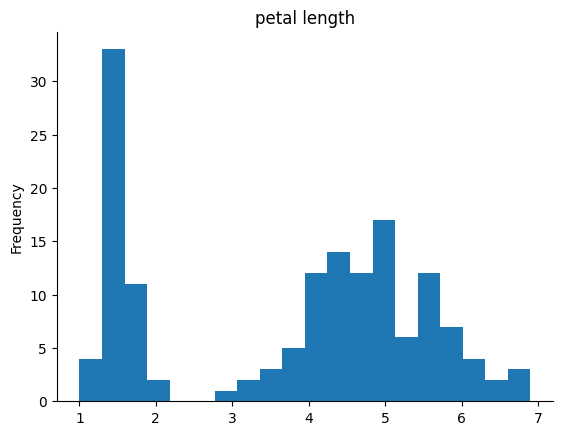

In [ ]:
# @title petal length

from matplotlib import pyplot as plt
X['petal length'].plot(kind='hist', bins=20, title='petal length')
plt.gca().spines[['top', 'right',]].set_visible(False)

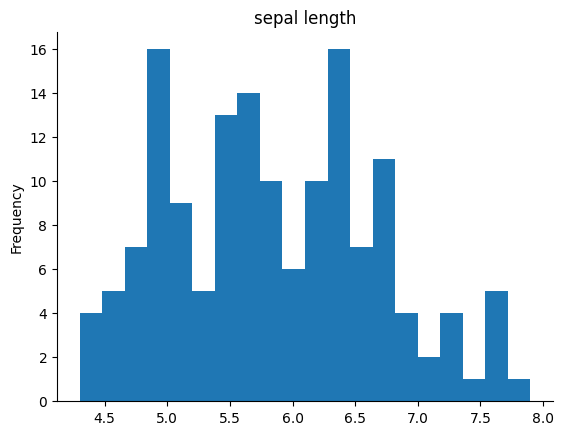

In [ ]:
# @title sepal length

from matplotlib import pyplot as plt
X['sepal length'].plot(kind='hist', bins=20, title='sepal length')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [6]:
from sklearn.preprocessing import StandardScaler


In [16]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [28]:
class_mapping = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}

y['class_numerical'] = y['class'].map(class_mapping)

<ipython-input-28-cf9cb95c37c9>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['class_numerical'] = y['class'].map(class_mapping)


In [166]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

In [175]:
class IrisNet(nn.Module):
    def __init__(self):
        super(IrisNet, self).__init__()
        self.fc1 = nn.Linear(4, 4)
        self.fc2 = nn.Linear(4, 4)
        self.fc2_1 = nn.Linear(4, 4)
        self.fc3 = nn.Linear(4, 3)
        self.relu = nn.ReLU()
        self.elu = nn.ELU()
        self.selu = nn.SELU()
        self.celu = nn.CELU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc2_1(x))
        x = self.fc3(x)
        return x


In [176]:
X = scaler.fit_transform(X)
class_mapping = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}

y['class_numerical'] = y['class'].map(class_mapping)


In [177]:
X = torch.tensor(X,
                 dtype=torch.float32)

y1 = torch.tensor(y['class_numerical'],
                  dtype=torch.long)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y1,
                                                    test_size=0.2,
                                                    random_state=42)

# Create TensorDatasets
train_dataset = TensorDataset(X_train,
                              y_train)
test_dataset = TensorDataset(X_test,
                             y_test)

# Create DataLoaders
batch_size = 150
train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          shuffle=True)
test_loader = DataLoader(test_dataset,
                         batch_size=batch_size,
                         shuffle=False)


In [178]:
model = IrisNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.RMSprop(model.parameters(), lr=0.01)

model_loss = []
num_epochs = 100
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0

    for inputs, labels in train_loader:
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model_loss.append(running_loss)
    # Print average loss per epoch
    epoch_loss = running_loss / len(train_loader)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

Epoch [10/100], Loss: 0.4278
Epoch [20/100], Loss: 0.2513
Epoch [30/100], Loss: 0.1510
Epoch [40/100], Loss: 0.0958
Epoch [50/100], Loss: 0.0729
Epoch [60/100], Loss: 0.0622
Epoch [70/100], Loss: 0.0567
Epoch [80/100], Loss: 0.0545
Epoch [90/100], Loss: 0.0505
Epoch [100/100], Loss: 0.0485


In [179]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate metrics using sklearn
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, digits=4))

# Alternatively, calculate individual metrics
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"\nWeighted Average Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10
           1     1.0000    1.0000    1.0000         9
           2     1.0000    1.0000    1.0000        11

    accuracy                         1.0000        30
   macro avg     1.0000    1.0000    1.0000        30
weighted avg     1.0000    1.0000    1.0000        30


Weighted Average Metrics:
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


In [147]:
_4_layer = model_loss

In [153]:
_5_layer = model_loss

In [164]:
_6_layer = model_loss

In [107]:
import matplotlib.pyplot as plt


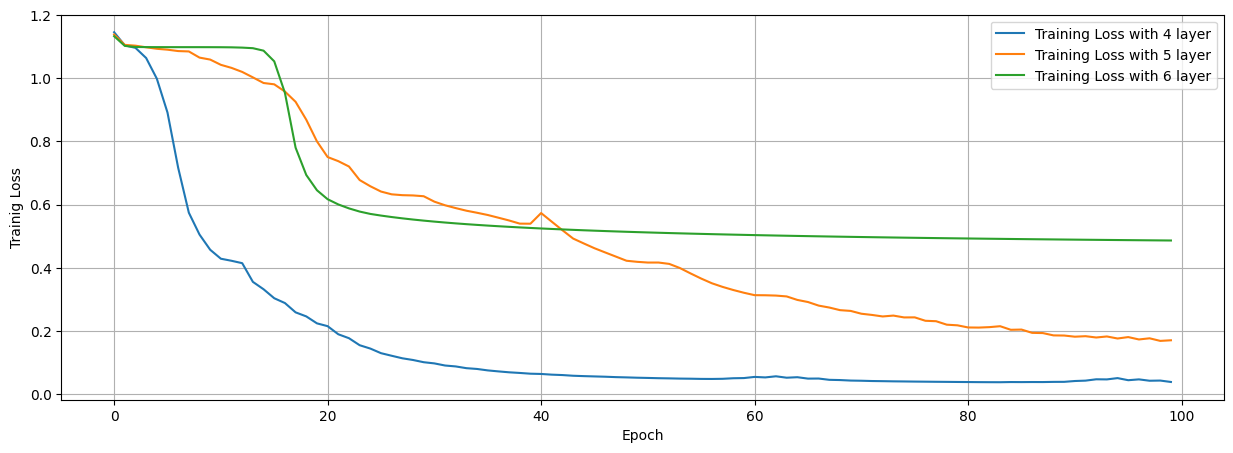

In [165]:
plt.figure(figsize=(15, 5))
plt.plot(_4_layer, label='Training Loss with 4 layer')
plt.plot(_5_layer, label='Training Loss with 5 layer')
plt.plot(_6_layer, label='Training Loss with 6 layer')
plt.xlabel('Epoch')
plt.ylabel('Trainig Loss')
plt.legend()
plt.grid()
plt.show()

In [ ]:
4 layer
Weighted Average Metrics:
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

In [ ]:
5 layer
weighted Average Metrics:
Precision: 0.9022
Recall: 0.8667
F1-Score: 0.8579

In [ ]:
6 layer
Weighted Average Metrics:
Precision: 0.4683
Recall: 0.6333
F1-Score: 0.5195